# Homework - 1

In this homework, you will get familiar with the basic pipeline for training deep neural networks (DNNs), including creation of datasets, dataloaders, model classes, etc. You will also conduct some experiments to understnad the impact of different setup choices.

**Note 0**: Some tasks are in the text form and ask for your analysis/response. It is usually written as `**Your response here:**`. Please do not delete this line and write your response after the two dots `:`.

**Note 1**: In the training pipeline, you must use [Comet](https://www.comet.com/site/) for the experiment tracking (logging loss, images, etc.). See [Seminar from Week 02](https://github.com/Blinorot/deep-learning-research/blob/2026/week02/Seminar.ipynb) for the guidelines. This is to avoid messy code and built good habits from the beginning of your journey.

**Important**: When submitting the homework, attach a `Comet Report` with sections for each of the tasks and corresponding plots for them.

**Note 2**: When writing code, preserve the chronological order of cells so the whole notebook can be run sequentially

**Note 3**: Several tasks require you to run the same pipeline with a slight modification. To make these tasks as pretty as possible (so it is easy to read and assess your work), aim to make you code **configurable**. For example, imagine we asked you to expore how the number of iterations impacts the performance and you want to try numbers in $[100, 1000, 10000]$. Instead of having three functions like this:

```python
def train_neural_net():
    for i in range(100):
        train_step(...)
```

```python
def train_neural_net():
    for i in range(1000):
        train_step(...)
```

```python
def train_neural_net():
    for i in range(10000):
        train_step(...)
```

You shall create only one with an argument `n_steps`, so you can call the same function easily with different values for this `n_steps`:

```python
def train_neural_net(n_steps):
    for i in range(n_steps):
        train_step(...)

train_neural_net(100)
train_neural_net(1000)
train_neural_net(10000)
```

Of course this relates not only to some hyperparameters like the number of steps or the hidden_dim of your model, but to the whole objects or classes (for example, running the pipeline with a DNN_1 and a DNN_2).

**Non-configured solutions that copy-paste large blocks of code will be penalized**

## COMET REPORT

https://www.comet.com/m-dumbduck/hse-dl-hw-1/reports

## Recalling basic concepts

Let's start by recalling what we've learned at the seminar by training a model on a toy dataset. While you are allowed to look at the seminar notebook, we **strongly** advise you to first try to implement the pipeline yourself, so you get some exposure to the `pytorch` functions/classes and better understand how it works. Use the seminar as a reference to double-check your pipeline or get a hint when you are stuck. Also, have a look at the PyTorch tutorials listed in the first seminar before you start.


In [1]:
%pip install comet-ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 19.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.3 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.3.2
    Uninstalling python-box-7.3.2:
      Successfully uninstalled python-box-7.3.2
Note: you may need to restart the kernel to use updated packages.


In [2]:
import comet_ml

In [3]:
import logging
logging.getLogger("comet_ml").setLevel(logging.ERROR)

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [5]:
from pathlib import Path

DATA_DIR = Path("data/").resolve()
DATA_DIR.mkdir(exist_ok=True, parents=True)

#### Task 1 [0.9pts]

Let's try to classify images of clothes. Download the FashionMNIST dataset using `torchvision` library.

In [6]:
import torchvision

In [7]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
    ]
)

In [8]:
fashion_mnist_train = torchvision.datasets.FashionMNIST(
    "./data/fashion_mnist/", train=True, download=True, transform=transform
)
fashion_mnist_val = torchvision.datasets.FashionMNIST(
    "./data/fashion_mnist/", train=False, download=True, transform=transform
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.0MB/s]


Visualize an image and calculate the number of classes in the dataset.

In [9]:
fashion_mnist_num_classes = fashion_mnist_train.targets.unique().shape[0]
print(f"Number of classes in the dataset: {fashion_mnist_num_classes}")

Number of classes in the dataset: 10


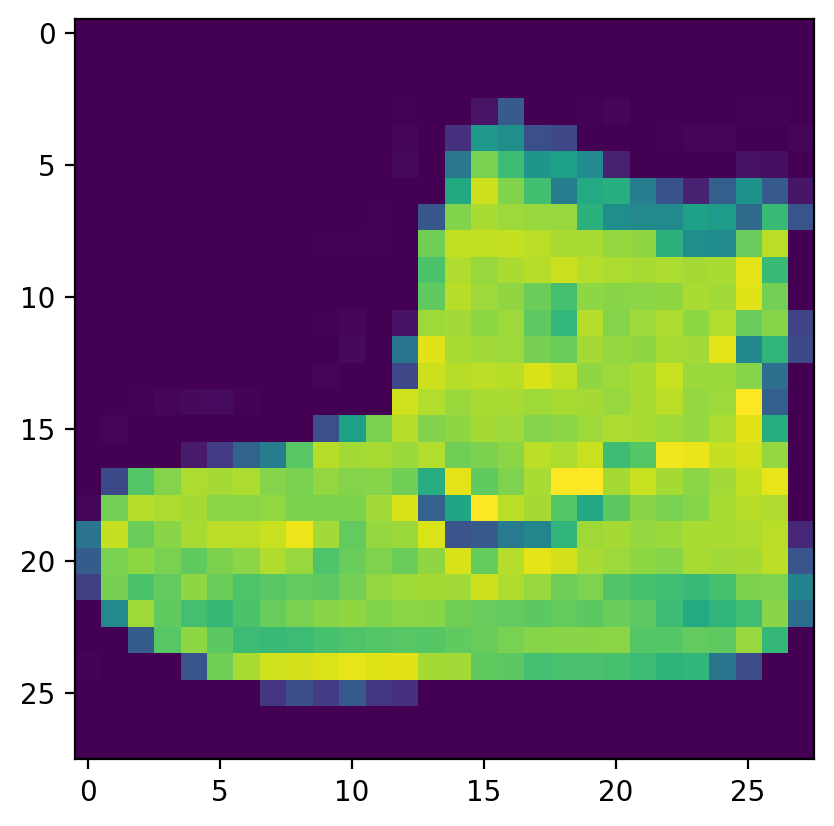

In [10]:
plt.imshow(fashion_mnist_train.data[0])
plt.show()

Create dataloaders to process your data in batches

In [11]:
import torch
import torch.nn as nn

In [12]:
train_loader = torch.utils.data.DataLoader(fashion_mnist_train, batch_size=256, shuffle=True)
val_loader = torch.utils.data.DataLoader(fashion_mnist_val, batch_size=256, shuffle=False)

Create a convolutional neural network with 6 layers to solve the classification task on this FashionMNIST dataset. Each even layer should downsample (downscale) the image by a factor of two (e.g. $28\times28 \to 14\times 14$) , while odd layers should keep the resolution untouched (e.g. $28\times28 \to 28\times 28$). You need to adjust convolution layer hyperparameters to achieve this. Use any activation of your interest in between. Finish with a Linear classification head.

In [13]:
class BaseCNN(nn.Module):
    def __init__(self, image_size, conv_channels: tuple = (1, 16, 32, 64, 128, 256, 512), strides: tuple = (1, 2, 1, 2, 1, 2), output_channels: int = 10):
        super().__init__()

        if len(conv_channels) != len(strides) + 1:
            raise ValueError("len(channels) must be equal to len(strides) + 1")

        image_size = list(image_size)
        layers = []
        for from_channel, to_channel, stride in zip(conv_channels, conv_channels[1:], strides):
            layers.extend([
                nn.Conv2d(from_channel, to_channel, kernel_size=3, stride=stride, padding=1),
                nn.ReLU()
            ])
            image_size[0] = (image_size[0] - 1) // stride + 1
            image_size[1] = (image_size[1] - 1) // stride + 1
        
        layers.extend([
            nn.Flatten(),
            nn.Linear(conv_channels[-1] * image_size[0] * image_size[1], output_channels)
        ])
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

Define a loss function to train your model to classify images of the given dataset. Which loss should you use?

In [14]:
criterion = nn.CrossEntropyLoss()

Write a training and evaluation loop. To see your loss/accuracy progress, log it using [WandB](https://wandb.ai/site/) or [CometML](https://www.comet.com/site/) experiment trackers.

**Note:** Avoid saving your private API key in the notebook.

In [15]:
comet_ml.login()

Please paste your Comet API key from https://www.comet.com/api/my/settings/
(api key may not show as you type)


Comet API key:  ········


In [16]:
from tqdm import tqdm

In [17]:
from torchvision.transforms.functional import to_pil_image

def train_epoch(epoch, model, criterion, optimizer, scheduler, loader, device, exp):
    model.train()
    
    avg_loss = 0
    total_elements = 0

    for batch_idx, (image, label) in enumerate(tqdm(loader)):
        image, label = image.to(device), label.to(device)

        optimizer.zero_grad()
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        scheduler.step()

        exp.log_metrics({
            "train_step_loss": loss.item(),
            "train_step_lr": scheduler.get_last_lr()[0],
        }, step=epoch * len(loader) + batch_idx)

        total_elements += output.shape[0]
        avg_loss += loss.item() * image.shape[0]

        if batch_idx == 0:
            exp.log_image(image_data=to_pil_image(image[0].detach().cpu()), name="train_image", step=epoch * len(loader) + batch_idx)

    avg_loss /= total_elements
    return avg_loss

def evaluate(epoch, model, criterion, loader, device, exp):
    model.eval()

    avg_loss = 0
    accuracy = 0
    total_elements = 0

    with torch.no_grad():
        for batch_idx, (image, label) in enumerate(tqdm(loader)):
            image, label = image.to(device), label.to(device)

            output = model(image)
            loss = criterion(output, label)

            accuracy += (output.argmax(-1) == label).sum().item()
            total_elements += output.shape[0]
            avg_loss += loss.item() * image.shape[0]

    avg_loss /= total_elements
    accuracy = 100 * accuracy / total_elements
    return avg_loss, accuracy

In [18]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, device, n_epochs, exp):
    for epoch in range(n_epochs):
        train_avg_loss = train_epoch(epoch, model, criterion, optimizer, scheduler, train_loader, device, exp)
        val_avg_loss, val_accuracy = evaluate(epoch, model, criterion, val_loader, device, exp)

        exp.log_metrics({
            "train_avg_loss": train_avg_loss,
            "val_avg_loss": val_avg_loss,
            "val_accuracy": val_accuracy,
        }, step=(epoch + 1) * len(train_loader))

        print(f'Epoch {epoch + 1}/{n_epochs} finished with {train_avg_loss=:.5f} {val_avg_loss=:.5f} {val_accuracy=:.2f}%')

Now train the model you've created on the given dataset using your pipeline. Evaluate the model every epoch.

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [20]:
NUM_EPOCHS = 10

In [21]:
base_cnn = BaseCNN(image_size=(28, 28), output_channels=fashion_mnist_num_classes).to(device)
optimizer = torch.optim.Adam(base_cnn.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
    T_max=NUM_EPOCHS * len(train_loader), eta_min=1e-4
)

In [22]:
exp = comet_ml.Experiment(project_name="HSE_DL_HW_1", log_git_metadata=False, log_git_patch=False)
exp.set_name("FashionMNIST-BaseCNN")
train(base_cnn, train_loader, val_loader, criterion, optimizer, scheduler, device, NUM_EPOCHS, exp)
exp.end()

100%|██████████| 40/40 [00:01<00:00, 28.98it/s]


Epoch 1/10 finished with train_avg_loss=0.60868 val_avg_loss=0.38990 val_accuracy=85.22%


100%|██████████| 40/40 [00:01<00:00, 31.97it/s]


Epoch 2/10 finished with train_avg_loss=0.33504 val_avg_loss=0.33365 val_accuracy=87.69%


100%|██████████| 40/40 [00:01<00:00, 31.26it/s]


...

Epoch 8/10 finished with train_avg_loss=0.13641 val_avg_loss=0.26523 val_accuracy=91.45%


100%|██████████| 40/40 [00:01<00:00, 28.92it/s]


Epoch 9/10 finished with train_avg_loss=0.11467 val_avg_loss=0.26088 val_accuracy=91.66%


100%|██████████| 40/40 [00:01<00:00, 31.68it/s]


Epoch 10/10 finished with train_avg_loss=0.09966 val_avg_loss=0.27597 val_accuracy=91.43%


In [23]:
print(f"Final accuracy: {evaluate(-1, base_cnn, criterion, val_loader, device, None)[1]}")

100%|██████████| 40/40 [00:01<00:00, 34.92it/s]

Final accuracy: 91.43


Run the final evaluation and print the final accuracy.

To get full score, you need to achieve $90\%$ accuracy on this dataset. Attach logs from the experiment tracker in the submission system 

#### Task 2 [0.1 pts]

How does the accuracy differs on the train and test sets (show)? Why is it so different?

**Your response here:**
Accuracy differs a lot, because model tries to better fit the train data, so it may overfit a bit. Consequently, train accuracy is high. Val accuracy corresponds to the model`s ability to generalize, so it will inevitably be lower.

In [24]:
print(f"Train accuracy: {evaluate(-1, base_cnn, criterion, train_loader, device, None)[1]}")
print(f"Val accuracy: {evaluate(-1, base_cnn, criterion, val_loader, device, None)[1]}")

100%|██████████| 235/235 [00:07<00:00, 33.11it/s]


Train accuracy: 97.005


100%|██████████| 40/40 [00:01<00:00, 33.83it/s]

Val accuracy: 91.43


## Understanding receptive field

In the previous subtask, you used many convolutions. Recall that each output element of the convolution sees only some local part of the layer's input -- the part that was in the overlap between the filter and the input.

The part of the input image that has some impact on the given output is called receptive field of the output (or more general a receptive field of the network). Making receptive field bigger means that the output starts depending on some part of the input it did not depend on previously. 

Visualizing this receptive field is quite easy using gradients:

1. Get input $x$, enable grad calculation for it using `requires_grad=True` and pass it through your convolution $f$.
2. Choose the element from the output $f(x)_{i, j}$ (specific pixel in the tensor) you are interested in.
3. Call `.backward` on this element to get gradients.
4. The pixels in the input that contributed to the output will have non-zero gradients. So, to get a receptive field, you compare gradients with zero

#### Task 3 [0.2 pts]

Explain why this approach actually shows the receptive field for the element:

**Your response here:**

Inferencing network is basically inferencing some function `f(input)`, where input is some tensor. So, if `f` is differentiable (it is our case), computing all the gradients with `.backward` will produce non-zero gradients for all the elements in input tensor that are used in `f` (lets assume it is impossible in practice to achive the situation where the some gradient would become zero because of its calculation at some function extremum).

#### Task 4 [0.3 pts]

Take an example image from the previous section. For the pixel of interest, consider the center pixel. 

Create a $3\times3$ and a $5\times5$ convolutions. How does their receptive fields differ? Explain with the visualization created using the algorithm described above

In [25]:
def draw_receptive_field(layer, image, show_plot=True, title=None, use_magnitude=False):
    input_image = image.detach().clone().unsqueeze(0).float().requires_grad_(True)
    output_image = layer(input_image)
    print(f"Output image shape: {output_image.shape}")
    output_image[0, output_image.shape[1] // 2, output_image.shape[2] // 2].backward()
    if title is None:
        plt.title(f"Receptive field:\n{layer}")
    else:
        plt.title(title)
    receptive_field = input_image.grad.squeeze().detach().numpy()
    if not use_magnitude:
        receptive_field = receptive_field != 0
    plt.imshow(receptive_field)
    if show_plot:
        plt.show()

In [26]:
conv_3x3 = nn.Conv2d(1, 1, kernel_size=3, padding=1)
conv_5x5 = nn.Conv2d(1, 1, kernel_size=5, padding=2)

Output image shape: torch.Size([1, 28, 28])


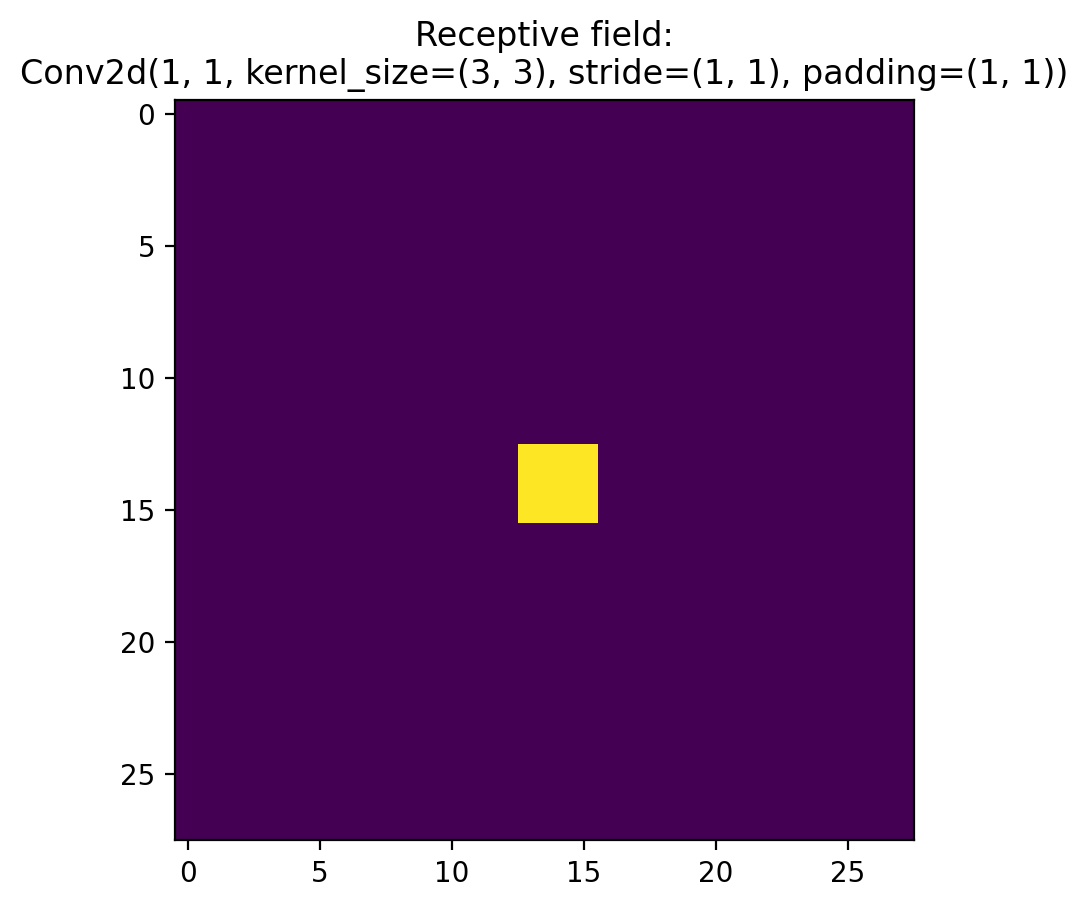

Output image shape: torch.Size([1, 28, 28])


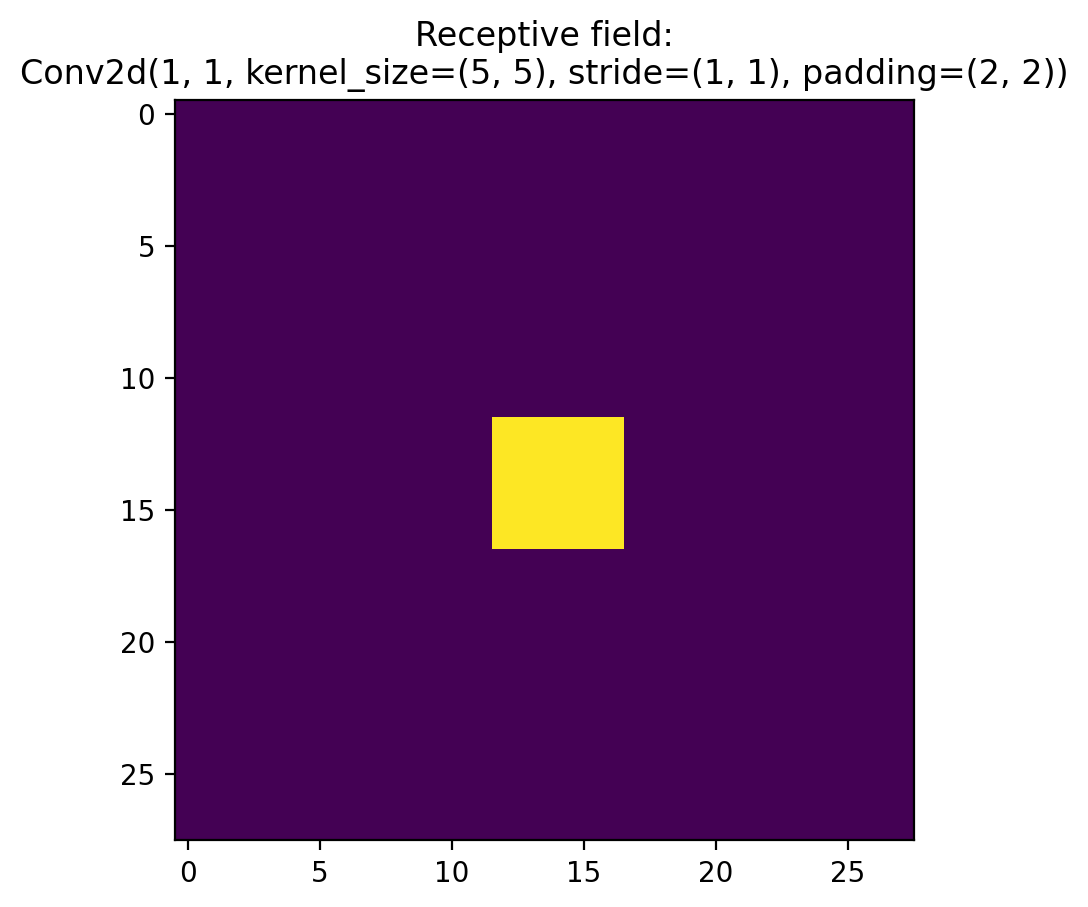

In [27]:
draw_receptive_field(conv_3x3, fashion_mnist_train.data[0])
draw_receptive_field(conv_5x5, fashion_mnist_train.data[0])

**Your response here**:
$3 \times 3$ convolution function involves $3 \times 3$ block with center in the output element, so the receptive field is $3 \times 3$, which is exactly what is shown. In $5 \times 5$ case it is all the same, except that convolution function involves $5 \times 5$ block with center in the output element.

Now plot how the receptive field changes when you use

1. A single $5\times 5$ convolution, while preserving the image shape (choose stride, padding)
2. Additionally use another $5\times 5$ convolution, while preserving the image shape (choose stride, padding)
3. Additionally downsample image by a factor of 2 using a $5\times 5$ convolution.
4. Additionally use another $5\times 5$ convolution, while preserving the image shape (choose stride, padding)
5. Additionally use another $5\times 5$ convolution, while preserving the image shape (choose stride, padding)
6. Additionally use another $5\times 5$ convolution, while preserving the image shape (choose stride, padding)

Hence, you have a model with 6 layers at the end and you should try the model with 1,2,3,4,5, and 6 layers (each layer definition is given above).


Output image shape: torch.Size([1, 28, 28])
Output image shape: torch.Size([1, 28, 28])
Output image shape: torch.Size([1, 14, 14])
Output image shape: torch.Size([1, 14, 14])
Output image shape: torch.Size([1, 14, 14])
Output image shape: torch.Size([1, 14, 14])


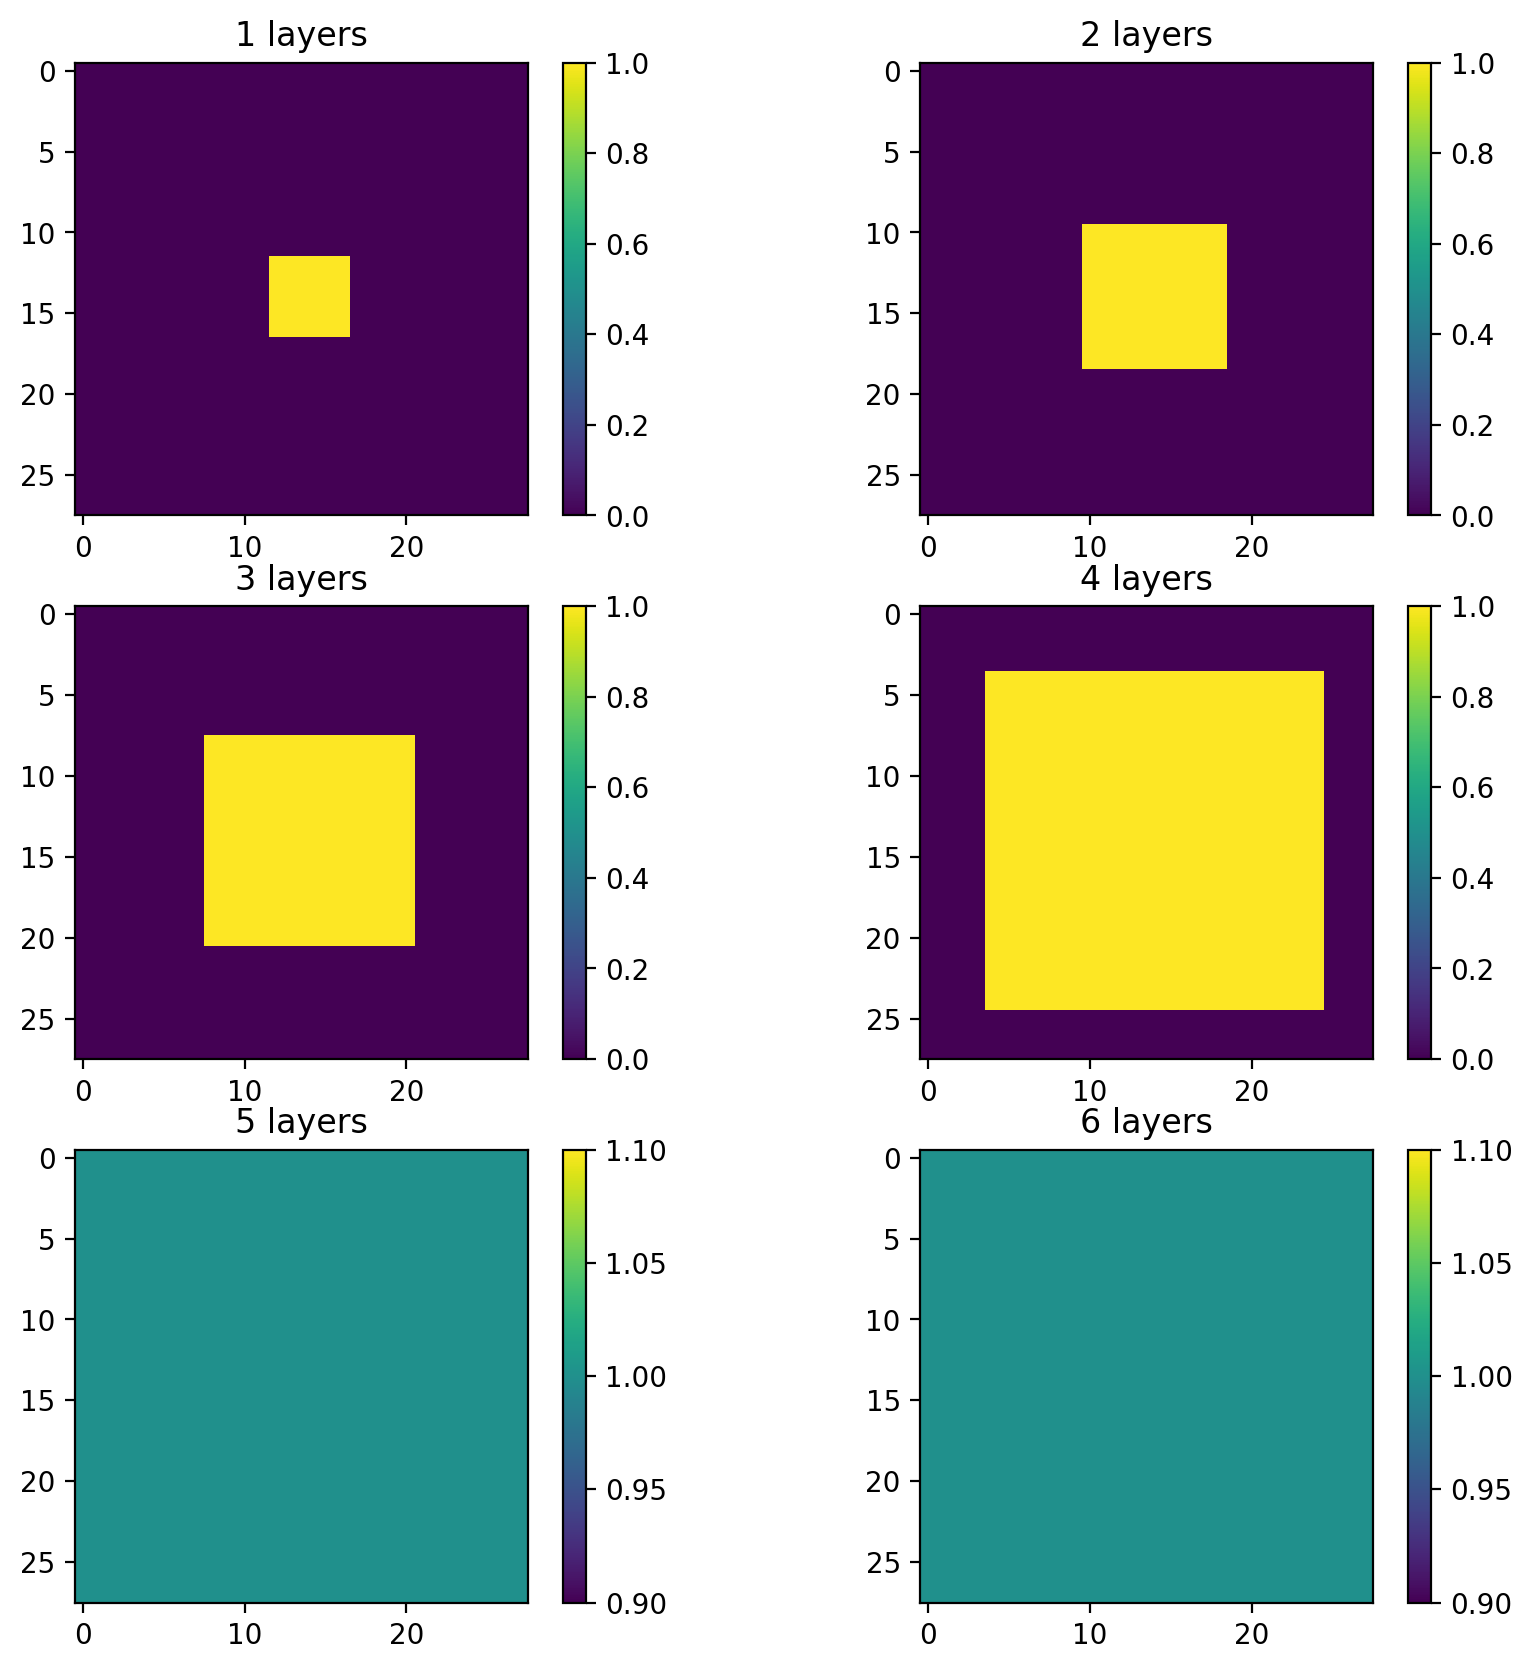

In [28]:
layers = [
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2, stride=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
]

plt.figure(figsize=(10, 10))
for i in range(len(layers)):
    plt.subplot(len(layers) // 2, 2, i + 1)
    draw_receptive_field(nn.Sequential(*layers[:i + 1]), fashion_mnist_train.data[0], show_plot=False, title=f'{i + 1} layers')
    plt.colorbar()

plt.show()

What can you say about the impact of the number of layers based on plots you created? Does the receptive field always change?

**Your response here**:

Downsampling image led to faster receptive field increase, with the same convolutional layers (comparison of $1 \rightarrow 2$ with $3 \rightarrow 4$). On $5$ th plot receptive field for our central pixel has already got all the pixels in input image, so $5 \rightarrow 6$ does not change anything.

If you use magnitude of the gradient values instead of a binary comparison with zero, you get a so-called saliency map. In reality, it is calculated based on loss and not a specific element of the output feature map, but the idea is similar. When calculated based on loss, saliency map surves as a simple XAI (explainable AI) method that shows how each element in the input contributed to the model's decision.

Below plot the magnitude version of the plots you did to get an idea of how it looks.

Output image shape: torch.Size([1, 28, 28])
Output image shape: torch.Size([1, 28, 28])
Output image shape: torch.Size([1, 14, 14])
Output image shape: torch.Size([1, 14, 14])
Output image shape: torch.Size([1, 14, 14])
Output image shape: torch.Size([1, 14, 14])


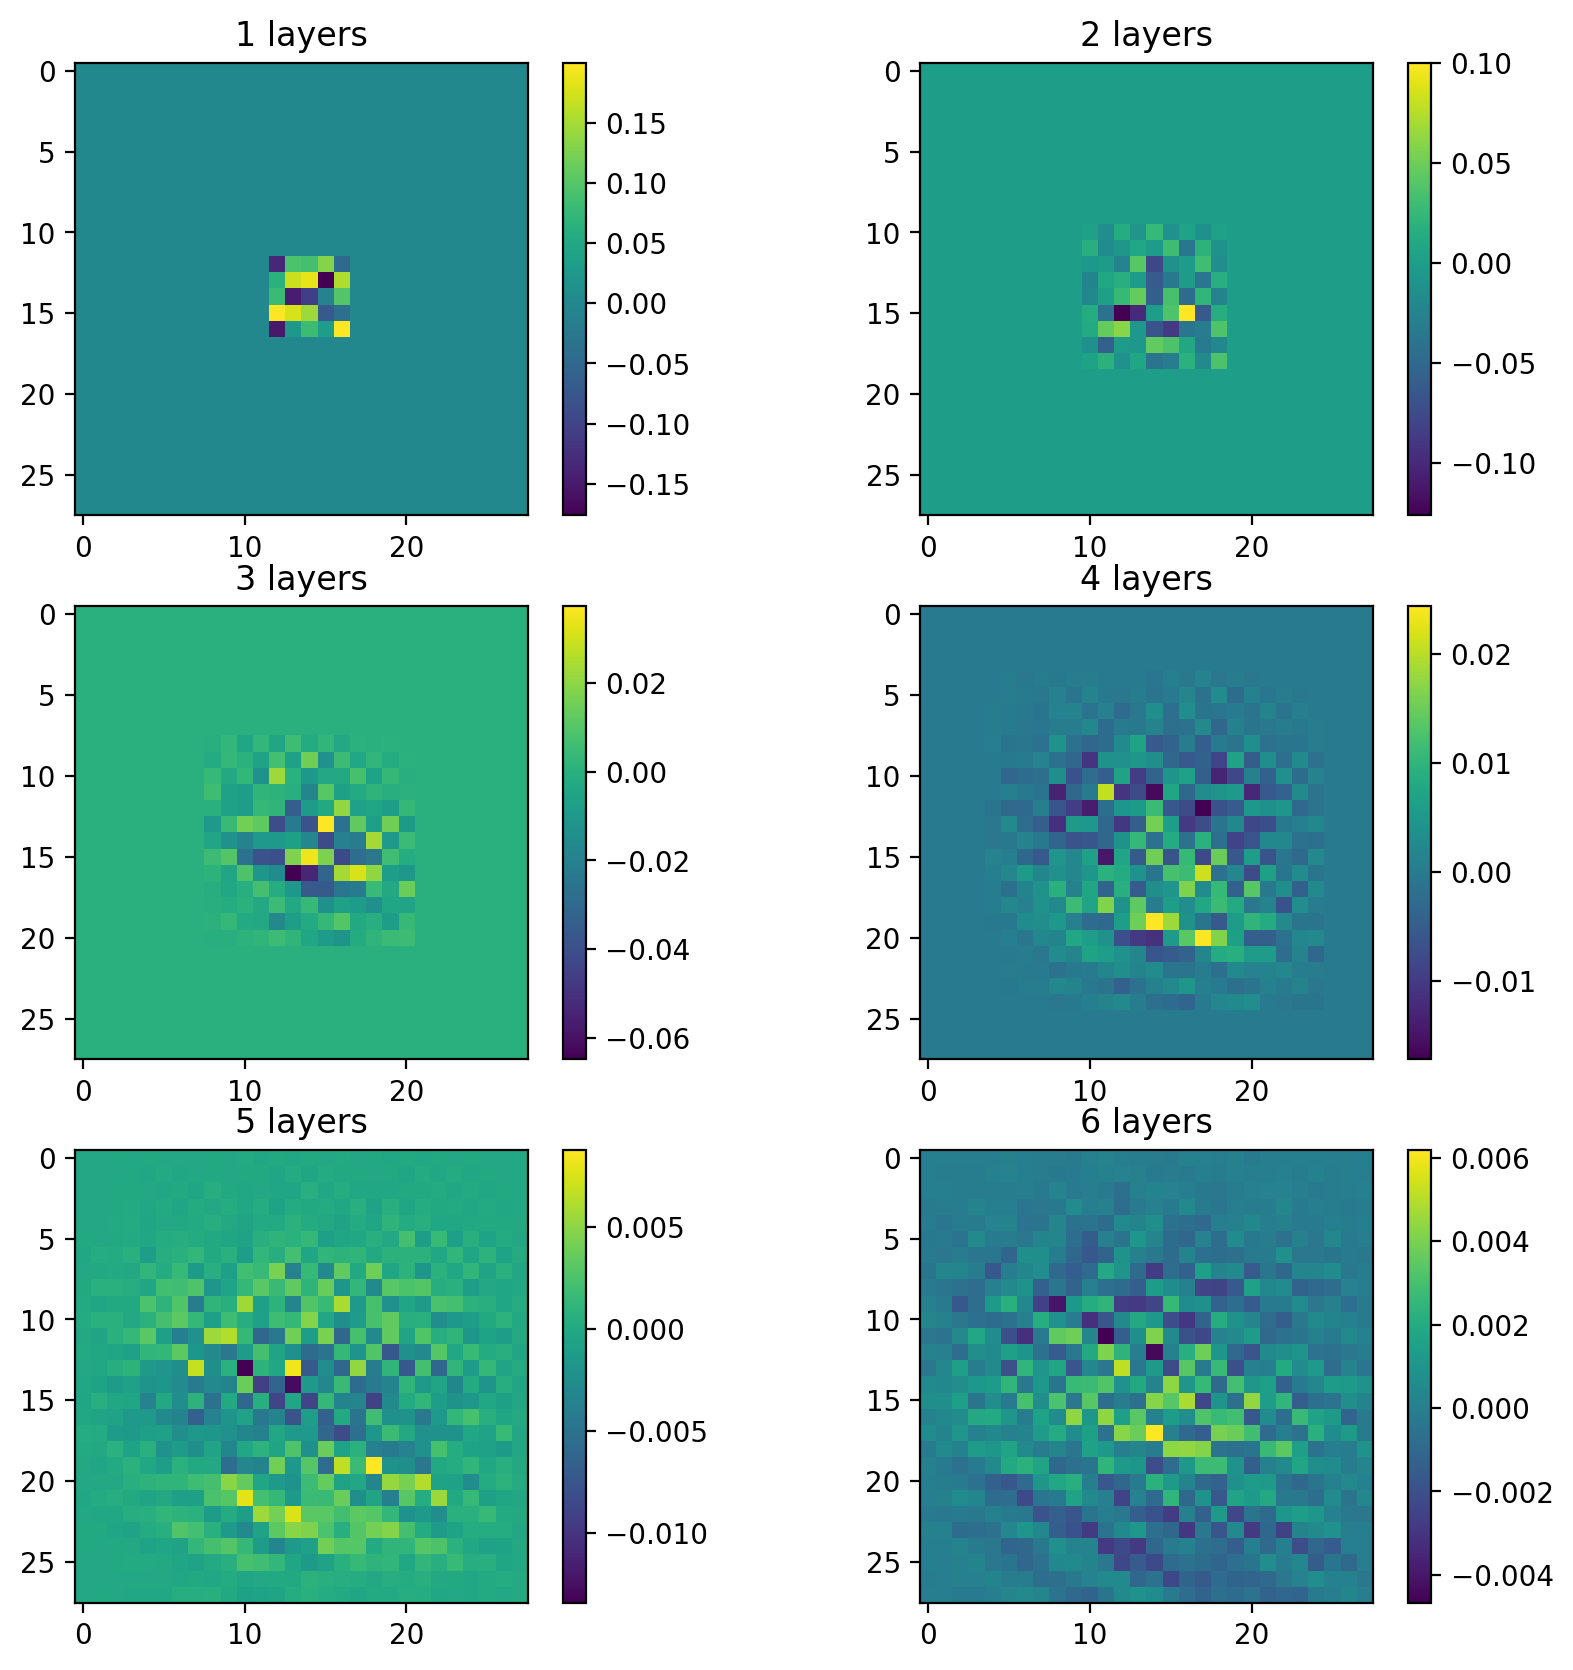

In [29]:
layers = [
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2, stride=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
    nn.Conv2d(1, 1, kernel_size=5, padding=2),
]

plt.figure(figsize=(10, 10))
for i in range(len(layers)):
    plt.subplot(len(layers) // 2, 2, i + 1)
    draw_receptive_field(nn.Sequential(*layers[:i + 1]), fashion_mnist_train.data[0], show_plot=False, title=f'{i + 1} layers', use_magnitude=True)
    plt.colorbar()

plt.show()

## Going Real

Now that the basic concepts are clear, let's try to train a model on a real dataset and understand the impact of the architecture design choices, learning rate, seed, and pre-training.

#### Task 5 [1 pts]

For this section, we will work with the Flowers102 dataset. Download it from `torchvision`. For simplicity, ignore the validation split and look only on train\test splits.

In [30]:
flowers102_train = torchvision.datasets.Flowers102(
    "./data/flowers102/", split="train", download=True, transform=transform
)
flowers102_test = torchvision.datasets.Flowers102(
    "./data/flowers102/", split="test", download=True, transform=transform
)
print(f"{len(flowers102_train)=}")
print(f"{len(flowers102_test)=}")

100%|██████████| 345M/345M [00:12<00:00, 27.8MB/s] 
100%|██████████| 502/502 [00:00<00:00, 1.19MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 30.8MB/s]


len(flowers102_train)=1020
len(flowers102_test)=6149


Visualize an image from the dataset and calculate the number of classes.

In [31]:
def visualize_flower(image_ind, dataset):
    print(f"Example flower: {flowers102_train.classes[dataset[image_ind][1]]}")
    plt.imshow(dataset[image_ind][0].permute(1, 2, 0))
    plt.show()

Number of classes in the dataset: 102
------------------------------------------------------------
Example flower: pink primrose


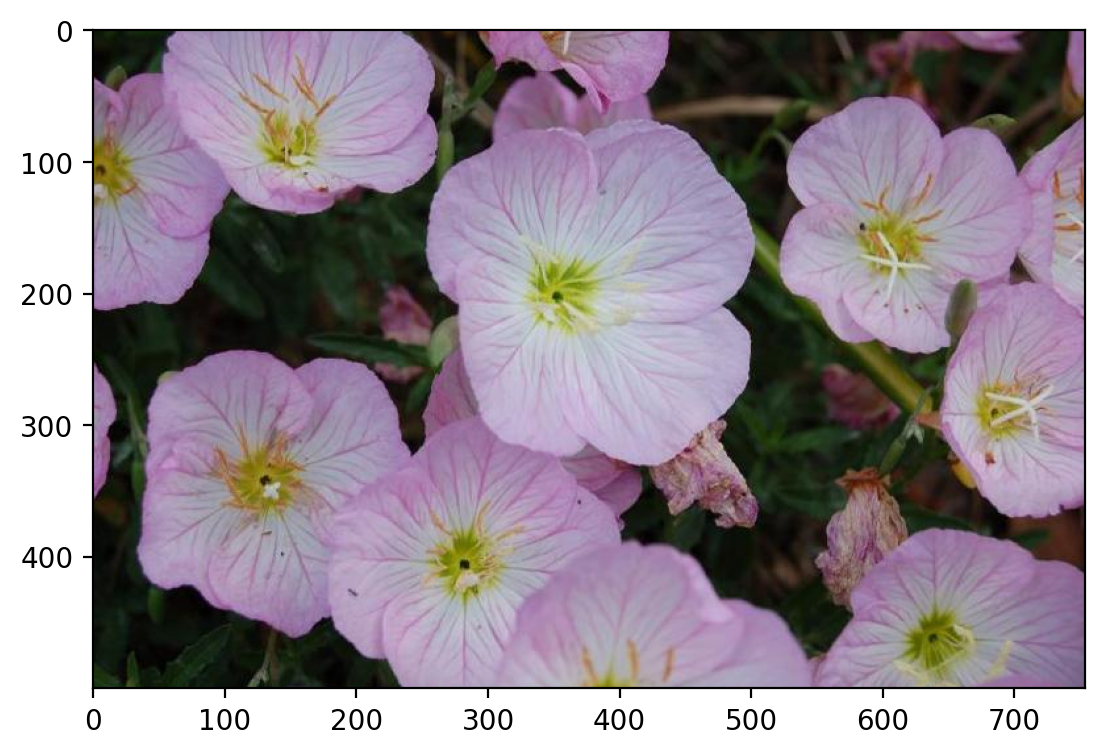

In [32]:
flowers102_class_number = len(flowers102_train.classes)
print(f"Number of classes in the dataset: {flowers102_class_number}")

print('-' * 60)
visualize_flower(0, flowers102_train)

Visualize another image

Example flower: corn poppy


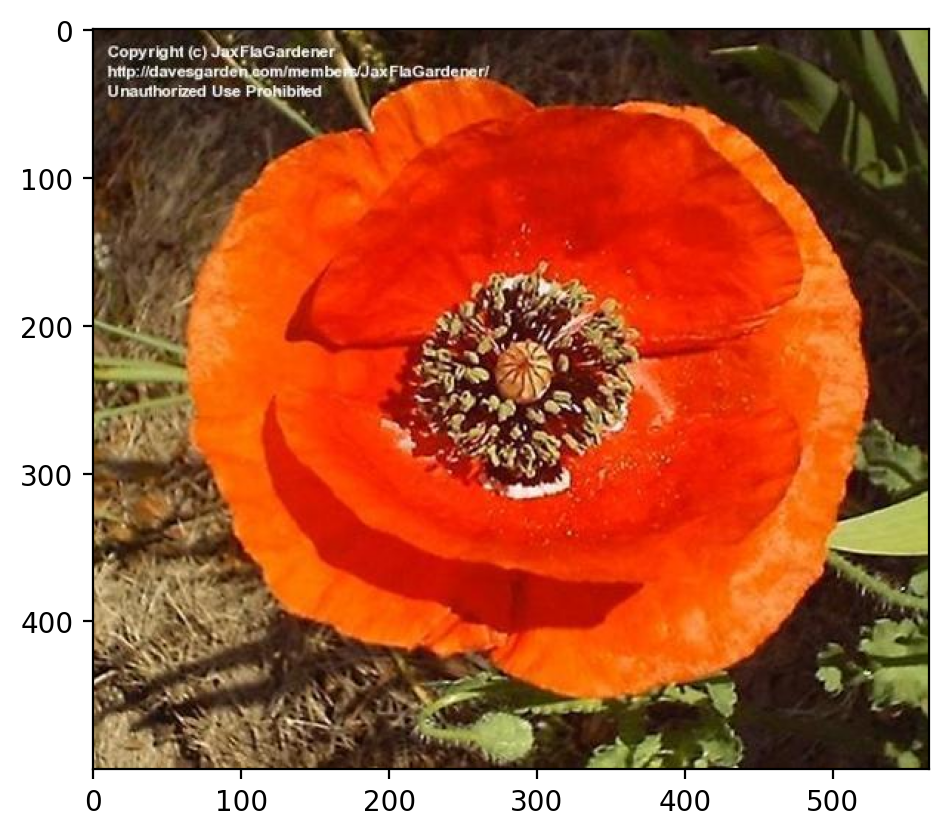

In [33]:
visualize_flower(250, flowers102_train)

Notice how the shape of an image is different. Explain why this can be a problem for training a neural network?

**Your response here:**

If we some images are smaller than other, but the CNN architecture stays the same, then we will use less convolutions in larger pictures due to the fact, that larger number of convolutions may cause size errors for smaller pictures. Also it will be harder for convolution layers to grasp information from pictures with different shapes, and also we would not be able to use Flatten in the end, because Linear head input depends on picture size (so we would be using adaptive poolings which are less efficient).

Modify the transforms to work with images of size `SIZExSIZE`. To do so, first resize images to $280\times 280$, then, take the center crop in test images and a random crop in train images. For the `SIZE`, use $224$.

In [34]:
RESIZE_SIZE = 280
SIZE = 224

train_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize(size=RESIZE_SIZE),
        torchvision.transforms.RandomCrop(size=SIZE),
        torchvision.transforms.ToTensor(),
    ]
)

test_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize(size=RESIZE_SIZE),
        torchvision.transforms.CenterCrop(size=SIZE),
        torchvision.transforms.ToTensor(),
    ]
)

In [35]:
flowers102_train = torchvision.datasets.Flowers102(
    "./data/flowers102/", split="train", download=True, transform=train_transform
)
flowers102_test = torchvision.datasets.Flowers102(
    "./data/flowers102/", split="test", download=True, transform=test_transform
)

Visualize an image from a train set and from a test set.

Train resized and randomly cropped flower
Example flower: pink primrose


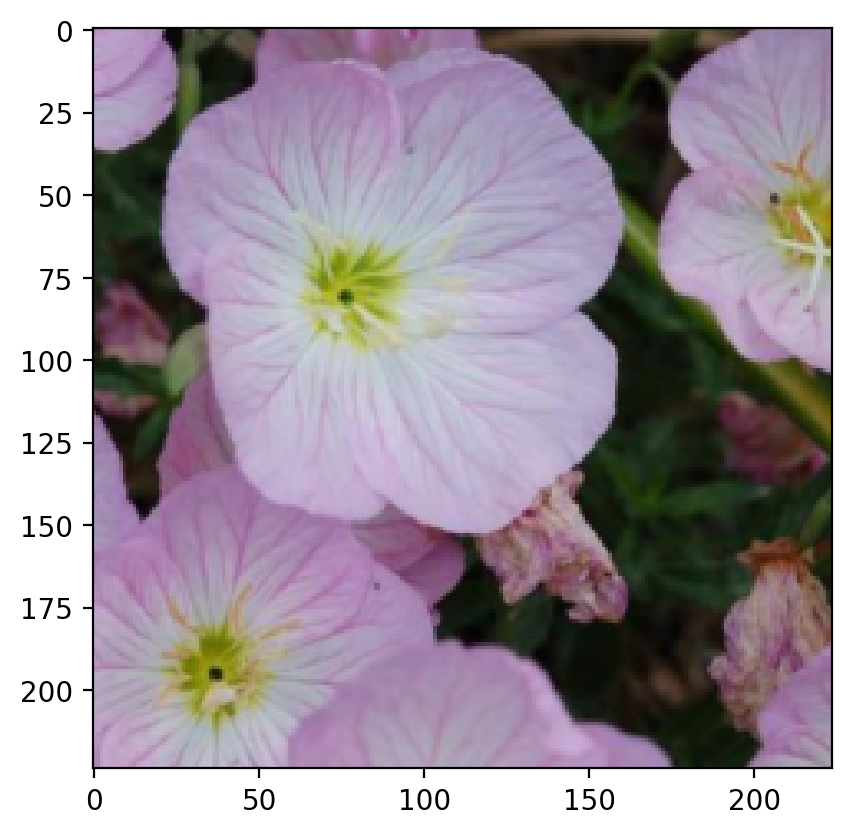

In [36]:
print("Train resized and randomly cropped flower")
visualize_flower(0, flowers102_train)

Test resized and center-cropped flower
Example flower: pink primrose


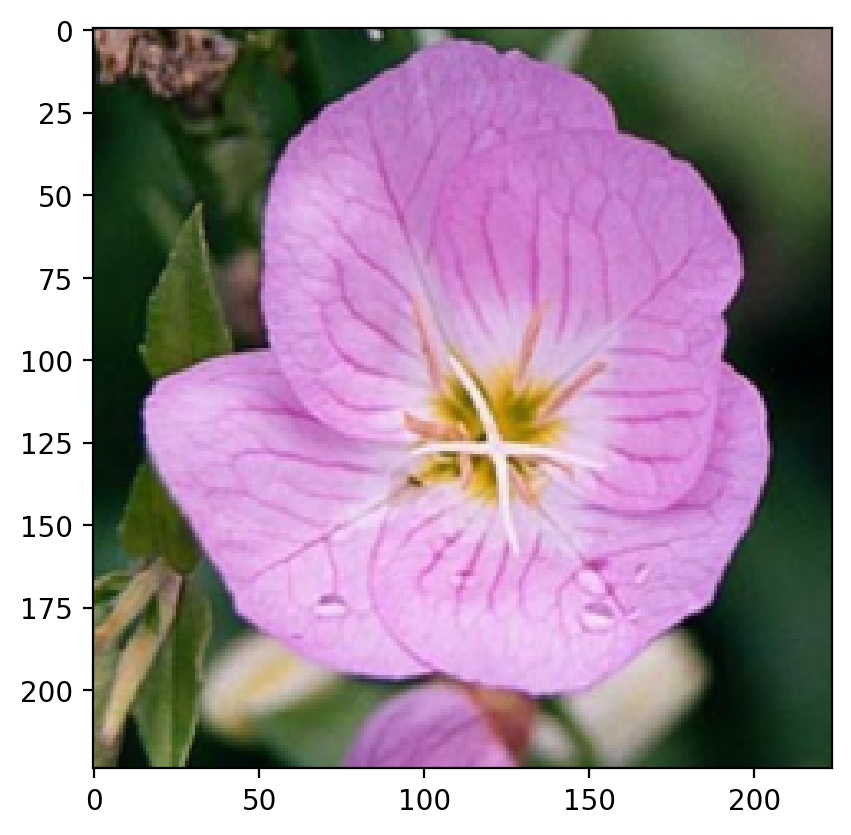

In [37]:
print("Test resized and center-cropped flower")
visualize_flower(0, flowers102_test)

Why having random crops is beneficial for training data? Why can't we use random crops for test?

**Your response here:**

Random crops is data augmentation and it can help model to generalize, especially in our case: we have train size around 1000 (with 102 classes) and test size around 6000. Augmentation helps to get more data for each class.

We cannot randomly crop on test, because the model performance on test may become unstable. We must have deterministic transforms for test dataset.

#### Task 6 [1 pts]

If you use a large batch size, the number of steps per epoch will be low becuase the training subset of data is rather small. This leads to an inefficient pipeline where you evaluate the model too often spending more time on evaluation rather than on the actual training.

To fix this, you can either repeat the dataset or modify the training pipeline to do eval once per $N$ training steps. The later approach is called iteration-based training, while the classic one we saw in the seminar is epoch-based (eval once per going over training data). Let's modify the pipeline to become an iteration based with $N=250$ steps per epoch.

To do so, we can loop the dataloader. Do it using Python `itertools` lib and create a wrapper class over the dataloader. The code should return a generator infinitely yielding from the dataloader. After $N$ steps in returns `StopIterator` until the next for-loop over it is called.

```python
loader = IterBasedDataLoader(loader)
for batch in loader: # N batches
   ...
```

In [38]:
from itertools import cycle

class IterBasedDataLoader:
    def __init__(self, loader, N):
        self.loader = loader
        self.iter_loader = cycle(loader)
        self.N = N
        self.cur = 0

    def __iter__(self):
        self.cur = 0
        return self

    def __next__(self):
        if self.cur >= self.N:
            raise StopIteration
        self.cur += 1
        return next(self.iter_loader)

    def __len__(self):
        return self.N

In [39]:
train_loader = IterBasedDataLoader(
    torch.utils.data.DataLoader(flowers102_train, batch_size=128, shuffle=True),
    N=250
)
test_loader = torch.utils.data.DataLoader(flowers102_test, batch_size=128, shuffle=False)

In [40]:
ind = 0
for x in train_loader:
    ind += 1
print(f"Batches processed: {ind}")

Batches processed: 250


**This trick is applied only on the train dataloader, not on a test one. Think why**

We do not need to see each test example more than once, because we want to evaluate our model performance accurately.

#### Task 7 [0.5 pts]

Take your neural network from the first Section and train it on this dataset for **10 epochs**. Do not use a scheduler (keep the learning rate constant) for this tasks and those below.

To make it work, you need to account for the difference in the datasets:

1. This dataset has another number of classes, so your classification head needs to be adjusted.
2. The images in the dataset are of the different size.
3. Previous dataset was in grayscale format and this one is in RGB.

For the learning rate, use `3e-4`.

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [42]:
def perform_experiment_flower102(model, lr, train_loader, test_loader, device, num_epochs, title):
    print('-' * 60)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ConstantLR(optimizer, factor=1, total_iters=0)
    exp = comet_ml.Experiment(project_name="HSE_DL_HW_1", log_git_metadata=False, log_git_patch=False)
    exp.set_name(title)
    train(model, train_loader, test_loader, criterion, optimizer, scheduler, device, num_epochs, exp)
    exp.end()
    print(f"Final accuracy: {evaluate(-1, model, criterion, test_loader, device, None)[1]:.2f}%\n")

In [43]:
base_cnn = BaseCNN(
    image_size=(SIZE, SIZE),
    output_channels=flowers102_class_number,
    conv_channels=(3, 8, 8, 8, 16, 16, 16),
).to(device)

perform_experiment_flower102(base_cnn, 3e-4, train_loader, test_loader, device, num_epochs=10, title="Flowers102-BaseCNN")

------------------------------------------------------------


100%|██████████| 49/49 [00:36<00:00,  1.35it/s]


Epoch 1/10 finished with train_avg_loss=2.06634 val_avg_loss=11.54813 val_accuracy=6.39%


100%|██████████| 49/49 [00:35<00:00,  1.37it/s]


Epoch 2/10 finished with train_avg_loss=0.00553 val_avg_loss=15.02830 val_accuracy=6.72%


...

Epoch 9/10 finished with train_avg_loss=0.00001 val_avg_loss=18.49651 val_accuracy=6.80%


100%|██████████| 49/49 [00:35<00:00,  1.37it/s]


Epoch 10/10 finished with train_avg_loss=0.00001 val_avg_loss=18.77771 val_accuracy=6.83%


100%|██████████| 49/49 [00:35<00:00,  1.38it/s]

Final accuracy: 6.83%



To get full score, you need to get $6.15\%$ accuracy (best) on this dataset using the described model.

#### Task 8 [1 pts]

Print the number of elements per split and plot the distribution of number of elements per class

In [44]:
print(f"{len(flowers102_train)=}")
print(f"{len(flowers102_test)=}")

len(flowers102_train)=1020
len(flowers102_test)=6149


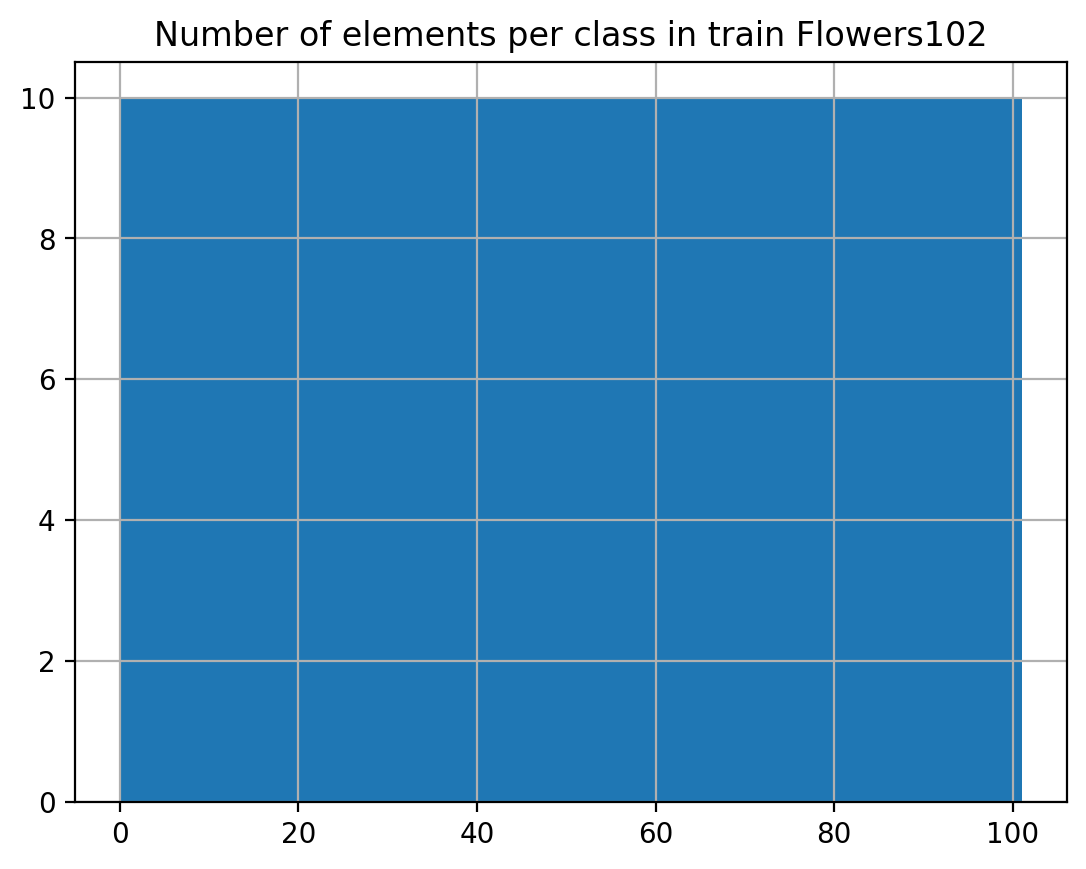

In [45]:
plt.title("Number of elements per class in train Flowers102")
plt.hist(list(map(lambda x: x[1], flowers102_train)), bins=flowers102_class_number)
plt.grid()
plt.show()

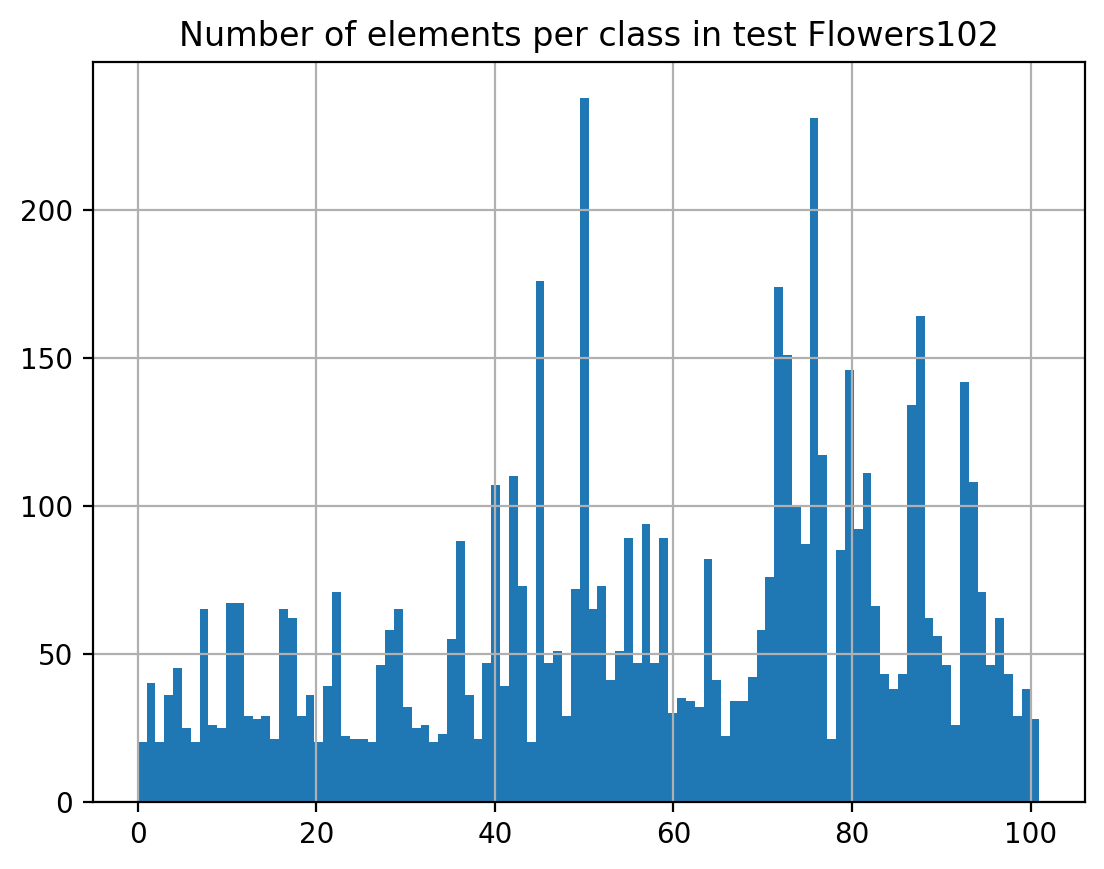

In [46]:
plt.title("Number of elements per class in test Flowers102")
plt.hist(list(map(lambda x: x[1], flowers102_test)), bins=flowers102_class_number)
plt.grid()
plt.show()

#### Task 9 [1 pts]

The number of elements per class is quite small. This explains the low accuracy of the model we trained before. It also explains why you see the accuracy decreasing after the last few epochs -- the model overfitted on the training data and started memorizing training images instead of actually undestanding why a flower belongs to a certain class.

It does not have enough knowledge about the world (flowers) to robustly predict classes on unseen data. Furthermore, the amount of data is quite small to learn useful image processing techniques that would extract useful information.

This is where pre-training helps. We can take a model trained on an extremely large corpora that has deep understanding of the visual modality. It already knows how to process images and how to extract useful information (edges, colors, shapes, etc.) that would be helpful for classification. 

Despite flowers being a different dataset, the model already acquired skills useful for image classification during its pre-training stage and can apply these skills and knowledge for the flowers classification task.

Let's use [ResNet18](https://arxiv.org/abs/1512.03385) (18 layers version). Download it from `torchvision` with pretrained weights from `IMAGENET1K_V1`. Similarly to a case seen previously, ResNet is trained on a dataset with 1000 classes, so you need to replace pre-trained final classification head with a new randomly initialized linear layer. To get the embedding size of the vector going inside this classification head, you can explore the hyperparameter variables of the pretrained head. 

Use `1e-5` for the learning rate.

In [47]:
from torchvision.models import resnet18, ResNet18_Weights

class Resnet(nn.Module):
    def __init__(self, output_features: int = 10, use_pretrained_weights=True):
        super().__init__()

        if use_pretrained_weights:
            weights = ResNet18_Weights.IMAGENET1K_V1
            self.resnet18_model = resnet18(weights=weights)
        else:
            self.resnet18_model = resnet18(weights=None)
        self.resnet18_model.fc = nn.Linear(self.resnet18_model.fc.in_features, output_features)

    def forward(self, x):
        return self.resnet18_model(x)

In [48]:
resnet18_model = Resnet(
    output_features=flowers102_class_number,
    use_pretrained_weights=True
).to(device)

perform_experiment_flower102(resnet18_model, 1e-5, train_loader, test_loader, device, num_epochs=10, title="Flowers102-Resnet18")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


------------------------------------------------------------


100%|██████████| 49/49 [00:38<00:00,  1.28it/s]


Epoch 1/10 finished with train_avg_loss=2.98320 val_avg_loss=3.04880 val_accuracy=55.41%


...

Epoch 9/10 finished with train_avg_loss=0.01829 val_avg_loss=1.46949 val_accuracy=82.39%


100%|██████████| 49/49 [00:38<00:00,  1.27it/s]


Epoch 10/10 finished with train_avg_loss=0.01444 val_avg_loss=1.43641 val_accuracy=82.68%


100%|██████████| 49/49 [00:38<00:00,  1.27it/s]

Final accuracy: 82.68%



To get the full score, you need to achieve $81\%$ accuracy

#### Task 10 [0.5 pts]

The accuracy is no doubt better! But, as in any research, we need to prove our methodology and investigate what actually matters and what does not. This is called **ablation studies**.

- The goal of an ablation study: understand if **Idea_i** is indeed beneficial or the real performance boost comes from other ideas.

- How to check: run the same training and evaluation using **identical** setups, except for one using **Idea_i** and another not using it.

- Why identical: if the setups differ in something else too, it is questionable whether the performance difference is due to absence of **Idea_i** or because of some other modification you did in your setup. So, you cannot assess the usefulness of the **Idea_i** anymore.

For example, if you want to compare model_1 and model_2, you cannot train one for 10 steps and another for 1000 steps because it is likely that the difference in their quality will be due to one being undertrained and not because of the model being worse architecture or methodology-wise. 

**Note:** For the fairest comparison, the setup shall be identical, but, of course, in reality, we often compare approaches with remarkably different setups. For example, when we compare a model from one paper with a model from another paper, they might have different training setups. But, in such a case, you need to remember that the quality difference is not only because the architectures are different, but also because of other modifications/tricks and optimization techniques the authors did for their models. 

**Research Note:** When you publish a paper with a new idea, you need to prove that your idea is actually working and useful. To do so, you need to provide some theoretical intuition/justification and experiemental results. The experimental results should include an ablation study with this idea being "turned off" to prove that the idea indeed adds benefit in practice. 

If you want to compare your final model with another model from the literature, you should ideally use the same train datasets. Otherwise, your superior performance may come from having another dataset and not from having a nice idea, so justifying that your idea is helpful will be hard in this case. There are other case-specific things to consider and think about but we hope you understood the principles. 

So, the question is, does the performance boost comes from having pretrained weights or from just having a better architecture than before? To prove that the weights are useful, train the same resnet model but with random initialized weights. Keep the rest of the setup the same

In [49]:
resnet18_model_no_pretrain = Resnet(
    output_features=flowers102_class_number,
    use_pretrained_weights=False
).to(device)

perform_experiment_flower102(resnet18_model_no_pretrain, 1e-4, train_loader, test_loader, device, num_epochs=10, title="Flowers102-Resnet18-NoPretrain")

------------------------------------------------------------


100%|██████████| 49/49 [00:38<00:00,  1.26it/s]


Epoch 1/10 finished with train_avg_loss=1.22373 val_avg_loss=3.02221 val_accuracy=31.89%


100%|██████████| 49/49 [00:38<00:00,  1.27it/s]


Epoch 2/10 finished with train_avg_loss=0.02212 val_avg_loss=3.01918 val_accuracy=32.09%


...

Epoch 9/10 finished with train_avg_loss=0.00084 val_avg_loss=3.05403 val_accuracy=31.94%


100%|██████████| 49/49 [00:38<00:00,  1.28it/s]


Epoch 10/10 finished with train_avg_loss=0.00067 val_avg_loss=3.05556 val_accuracy=32.10%


100%|██████████| 49/49 [00:38<00:00,  1.26it/s]

Final accuracy: 32.10%



What can you say about the impact of pretrained weights after comparing the two runs?

**Your response here:**

Pretrained weights allow model to be aware of image structure, so it mainly trains its head to compare these structures for different classes, and trains its other layers a bit to fit the task (so lr have to be quite small). Whereas for the case of random weights, model does not know much about image structure and quickly overfits on traing data, without trying to generalize.

#### Task 11 [1 pts]

Anyway, we see that random ResNet is better than our old CNN too. This means that the architecture design of ResNet is better than those of our CNN. But what is so special about ResNet? ResNet has these residual connections and batchnorm inside that stabilize the training and help model converge faster and better.

Maybe ResNet is better because of these tricks. But another important factor is model size. Model size (i.e. the number of parameters) defines the model capacity. In simple words, "how much knowledge can the model assimilate". If the model is too small, it might be that the model just does not have enough capacity to learn the required skills. There is a whole research topic named [TinyML](https://ieeexplore.ieee.org/document/10177729) aiming for making small models perform as great as possible, but, in general, it is reasonable that larger models perform better (e.g. LLM case) (*Note*: given that we have enough data and, therefore, do not overfit).

So maybe our CNN works so much worse just because it is much smaller and not because of the ResNet tricks. Let's investigate it.

Calculate the number of parameters in both models using `.numel` and `model.parameters`.

In [50]:
base_cnn = BaseCNN(
    image_size=(SIZE, SIZE),
    output_channels=flowers102_class_number,
    conv_channels=(3, 8, 8, 8, 8, 16, 16),
)
print(f"BaseCNN total parameters: {sum(p.numel() for p in base_cnn.parameters())}")
resnet18_model_no_pretrain = Resnet(
    output_features=flowers102_class_number,
    use_pretrained_weights=False
)
print(f"Resnet total parameters: {sum(p.numel() for p in resnet18_model_no_pretrain.parameters())}")

BaseCNN total parameters: 1285054
Resnet total parameters: 11228838


Indeed, our old model is way smaller. Create a new model with your own design that would have roughly similar number of parameters compared to ResNet. Do not add any tricks, let it be just a simple large CNN. Train in within the same setup and compare the performance. 

In [51]:
large_base_cnn = base_cnn = BaseCNN(
    image_size=(SIZE, SIZE),
    output_channels=flowers102_class_number,
    conv_channels=(3, 8, 16, 32, 64, 128, 256, 512, 768),
    strides=(1, 3, 1, 2, 1, 2, 1, 2)
).to(device)

print(f"LargeBaseCNN total parameters: {sum(p.numel() for p in large_base_cnn.parameters())}")

perform_experiment_flower102(large_base_cnn, 1e-4, train_loader, test_loader, device, num_epochs=10, title="Flowers102-LargeBaseCNN")

LargeBaseCNN total parameters: 12947126
------------------------------------------------------------


100%|██████████| 49/49 [00:37<00:00,  1.31it/s]


Epoch 1/10 finished with train_avg_loss=1.85087 val_avg_loss=20.01562 val_accuracy=5.27%


100%|██████████| 49/49 [00:37<00:00,  1.32it/s]


Epoch 2/10 finished with train_avg_loss=0.01464 val_avg_loss=23.29591 val_accuracy=5.61%


...

Epoch 9/10 finished with train_avg_loss=0.00000 val_avg_loss=26.64950 val_accuracy=5.85%


100%|██████████| 49/49 [00:37<00:00,  1.32it/s]


Epoch 10/10 finished with train_avg_loss=0.00000 val_avg_loss=26.82149 val_accuracy=5.92%


100%|██████████| 49/49 [00:36<00:00,  1.33it/s]

Final accuracy: 5.92%



What can you say about the usefulness of ResNet tricks after this experiment?

**Your response here**

ResNet tricks work, providing better performing architecture, than plain row of convolutions. LargeBaseCNN actually performs no better than BaseCNN, I guess because BaseCNN already contains enough parameters for grasping all general info it can get (with its simple architecture) and adding parameters only makes overfitting faster.

#### Task 11 [1 pts]

Let's return to ResNet. We said to use `1e-5` for the learning rate. This task will explain why. 

Compare the following runs using ResNet with **pretrained** weights:

1. A run with a learning rate inside $10^{1}$.
2. A run with a learning rate inside $10^{-2}$.
3. A run with a learning rate inside $5 \cdot 10^{-4}$.
4. A run with a learning rate inside $10^{-5}$.
5. A run with a learning rate inside $10^{-8}$.

Include a run with a random initialization where you use $10^{-2}$.

For this task you can use 5 epochs.

In [52]:
for lr in [1e1, 1e-2, 5e-4, 1e-5, 1e-8]:
    print(f"Training ResNet with pretrained weights and {lr=}")
    resnet18_model = Resnet(
        output_features=flowers102_class_number,
        use_pretrained_weights=True
    ).to(device)
    perform_experiment_flower102(resnet18_model, lr, train_loader, test_loader, device, num_epochs=5, title=f"Flowers102-Resnet18-{lr=}")

Training ResNet with pretrained weights and lr=10.0
------------------------------------------------------------


100%|██████████| 49/49 [00:37<00:00,  1.30it/s]


Epoch 1/5 finished with train_avg_loss=428.32468 val_avg_loss=6.49777 val_accuracy=1.02%


100%|██████████| 49/49 [00:36<00:00,  1.33it/s]


Epoch 2/5 finished with train_avg_loss=5.69428 val_avg_loss=6.30236 val_accuracy=0.34%


...

Epoch 4/5 finished with train_avg_loss=4.81904 val_avg_loss=4.81714 val_accuracy=0.83%


100%|██████████| 49/49 [00:38<00:00,  1.28it/s]


Epoch 5/5 finished with train_avg_loss=4.81363 val_avg_loss=4.81444 val_accuracy=0.85%


100%|██████████| 49/49 [00:38<00:00,  1.27it/s]

Final accuracy: 0.85%



In [53]:
lr = 1e-2
print(f"Training ResNet no pretrained weights and {lr=}")
resnet18_model = Resnet(
    output_features=flowers102_class_number,
    use_pretrained_weights=False
).to(device)
perform_experiment_flower102(resnet18_model, lr, train_loader, test_loader, device, num_epochs=5, title=f"Flowers102-Resnet18-NoPretrain-{lr=}")

Training ResNet no pretrained weights and lr=0.01
------------------------------------------------------------


100%|██████████| 49/49 [00:38<00:00,  1.26it/s]


Epoch 1/5 finished with train_avg_loss=2.61198 val_avg_loss=5.56568 val_accuracy=19.27%


100%|██████████| 49/49 [00:39<00:00,  1.23it/s]


Epoch 2/5 finished with train_avg_loss=0.09856 val_avg_loss=7.12114 val_accuracy=19.91%


...

Epoch 4/5 finished with train_avg_loss=0.00034 val_avg_loss=6.88717 val_accuracy=26.13%


100%|██████████| 49/49 [00:40<00:00,  1.20it/s]


Epoch 5/5 finished with train_avg_loss=0.00021 val_avg_loss=6.96440 val_accuracy=26.38%


100%|██████████| 49/49 [00:40<00:00,  1.21it/s]

Final accuracy: 26.38%



Compare the results for each of the learning rate groups. What can you say about each learning group rate? Why the performance became worse/better? How do they compare to the performance of a random initialization? Conclude the connection between usefulness of pretraining and the learning rate used during fine-tuning

**Your response here**

Pretrained model weights are a good starting position for model parameter optimization, so large learning rates (1e1, 1e-2) may lead to unpredictable jumps, which can negate all the benefit obtained from pretraining, leaving us with roughly random weights (we can see that for lr=1e-2 accuracy for pretrained vs random weights is roughly the same). Learning rates 5e-4 and 1e-5 worked great, because they did not ruin the starting position and only optimized it more. Learning rate 1e-8 did not work at all because it makes optimizer steps too small.

#### Task 12 [0.5 pts]

Now, let's understand the impact of randomness. Train ResNet 3 times starting from a random initiazliation and compare the accuracy obtained. Use 5 epochs.

In [54]:
for trial in range(3):
    print(f"Training ResNet without pretrained weights Trial {trial}")
    resnet18_model = Resnet(
        output_features=flowers102_class_number,
        use_pretrained_weights=False
    ).to(device)
    perform_experiment_flower102(resnet18_model, 1e-4, train_loader, test_loader, device, num_epochs=5, title=f"Flowers102-Resnet18")

Training ResNet without pretrained weights Trial 0
------------------------------------------------------------


100%|██████████| 49/49 [00:40<00:00,  1.21it/s]


Epoch 1/5 finished with train_avg_loss=1.22656 val_avg_loss=2.99887 val_accuracy=32.07%


100%|██████████| 49/49 [00:40<00:00,  1.21it/s]


Epoch 2/5 finished with train_avg_loss=0.02261 val_avg_loss=3.00340 val_accuracy=32.09%


...

Epoch 4/5 finished with train_avg_loss=0.00433 val_avg_loss=3.05136 val_accuracy=33.11%


100%|██████████| 49/49 [00:39<00:00,  1.25it/s]


Epoch 5/5 finished with train_avg_loss=0.00276 val_avg_loss=3.05360 val_accuracy=33.16%


100%|██████████| 49/49 [00:38<00:00,  1.27it/s]

Final accuracy: 33.16%



How does randomness affect performance? Conclude what special treatment do we need if we want reproducible experiments?

**Your response here:**

Random weights initialization has large effect on model training. Some initializations may be better than the other and it is impossible to predict which will be better. We see that model 3  achieved 33% accuracy on the second epoch, while model 1 struggles to achieve more than 32.14% accuracy after 5 epochs. 

Special treatment
We can fix as much random seeds as possible and tell torch to use deterministic algorithms. Usage of deterministic algorithms may slow down the training process a bit. We will get more or less stable performance for different experiments with the same setup.

#### Task 13 [1 pts]

Finally, let's understand why we chose `SIZE`to be $224$. Resize the $224 \times 224$ images from your dataset into $128\times 128$. 

In [55]:
RESIZE_SIZE = 160
SIZE = 128

train_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize(size=RESIZE_SIZE),
        torchvision.transforms.RandomCrop(size=SIZE),
        torchvision.transforms.ToTensor(),
    ]
)

test_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize(size=RESIZE_SIZE),
        torchvision.transforms.CenterCrop(size=SIZE),
        torchvision.transforms.ToTensor(),
    ]
)

flowers102_train = torchvision.datasets.Flowers102(
    "./data/flowers102/", split="train", download=True, transform=train_transform
)
flowers102_test = torchvision.datasets.Flowers102(
    "./data/flowers102/", split="test", download=True, transform=test_transform
)

train_loader = IterBasedDataLoader(
    torch.utils.data.DataLoader(flowers102_train, batch_size=128, shuffle=True),
    N=250
)
test_loader = torch.utils.data.DataLoader(flowers102_test, batch_size=128, shuffle=False)

Now train a ResNet starting from **pretrained** weights using `1e-5` learning rate.

In [56]:
resnet18_model = Resnet(
    output_features=flowers102_class_number,
    use_pretrained_weights=True
).to(device)
perform_experiment_flower102(resnet18_model, 1e-5, train_loader, test_loader, device, num_epochs=10, title=f"Flowers102-128x128-Resnet18")

------------------------------------------------------------


100%|██████████| 49/49 [00:28<00:00,  1.71it/s]


Epoch 1/10 finished with train_avg_loss=2.69752 val_avg_loss=3.33993 val_accuracy=39.23%


100%|██████████| 49/49 [00:28<00:00,  1.72it/s]


Epoch 2/10 finished with train_avg_loss=0.62013 val_avg_loss=2.77473 val_accuracy=55.78%


...

Epoch 9/10 finished with train_avg_loss=0.01467 val_avg_loss=2.12713 val_accuracy=65.07%


100%|██████████| 49/49 [00:28<00:00,  1.70it/s]


Epoch 10/10 finished with train_avg_loss=0.01172 val_avg_loss=2.08883 val_accuracy=65.64%


100%|██████████| 49/49 [00:28<00:00,  1.72it/s]

Final accuracy: 65.64%



Compare the achieved results with a pretrained version and a random-initialized version that used $224 \times 224$ images. Knowing that ResNet used $224\times 224$ images during pre-training on a large corpora, explain the observed performance:

**Your response here:**

ResNet had a large pretrain on $224 \times 224$ images and its convolution layers are used to feature extraction from the $224 \times 224$ picture scale. $128 \times 128$ pictures are smaller and convolution layers have to adapt to extract and combine information from more compact regions. These issues have negative effect on model`s performance. Also $128 \times 128$ images basically contain $3$ times less information.